# Chapter 2.2 : Quantum Mechanics (§2.8 – §2.16)

**Source:** *Computational Chemistry* (Oxford Chemistry Primers)

Sections covered here: configuration interaction, *ab initio* methods, correlation energy, semi-empirical
calculations, neglect of differential overlap, calculated energy properties, charge distribution
calculations, static indices.

Chapter 2.1 built the Hartree-Fock machinery and used it on H₂. This notebook takes that converged wave
function and asks what is still wrong with it, what can be built on top of it, and what can be extracted
from it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.optimize import minimize_scalar

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

BOHR = 0.529177210903          # angstrom per bohr
HARTREE_EV = 27.211386
HARTREE_KJ = 2625.4996

# --- basis sets: contracted s-type Gaussians, (exponent, coefficient) per shell
BASIS = {
    ("H", "STO-3G"):  [[(3.425250914, 0.154328967), (0.623913730, 0.535328142),
                        (0.168855404, 0.444634542)]],
    ("He", "STO-3G"): [[(6.362421394, 0.154328967), (1.158922999, 0.535328142),
                        (0.313649791, 0.444634542)]],
    ("H", "6-31G"):   [[(18.7311370, 0.03349460), (2.8253937, 0.23472695),
                        (0.6401217, 0.81375733)],
                       [(0.1612778, 1.0)]],
    ("He", "6-31G"):  [[(38.4216340, 0.0237660), (5.7780300, 0.1546790),
                        (1.0577900, 0.4696300)],
                       [(0.2402090, 1.0)]],
    ("H", "6-311G"):  [[(33.86500, 0.0254938), (5.094790, 0.190373), (1.158790, 0.852161)],
                       [(0.325840, 1.0)], [(0.102741, 1.0)]],
    ("He", "6-311G"): [[(98.12430, 0.0287452), (14.76890, 0.208061), (3.318830, 0.837635)],
                       [(0.874047, 1.0)], [(0.244564, 1.0)]],
}


def build_shells(atoms, basis):
    """Expand a list of (element, position) into normalised contracted s functions."""
    shells, owner = [], []
    for index, (element, position) in enumerate(atoms):
        for shell in BASIS[(element, basis)]:
            shells.append((np.array(position, float),
                           [(a, c * (2 * a / np.pi) ** 0.75) for a, c in shell]))
            owner.append(index)
    return shells, np.array(owner)


def boys_F0(t):
    return 1.0 if t < 1e-12 else 0.5 * np.sqrt(np.pi / t) * erf(np.sqrt(t))


def gaussian_product(a, A, b, B):
    p = a + b
    return p, (a * A + b * B) / p, np.exp(-a * b / p * np.dot(A - B, A - B))


def compute_integrals(shells, centres, charges):
    """Overlap, kinetic, nuclear attraction and two-electron integrals."""
    n = len(shells)
    S = np.zeros((n, n)); T = np.zeros((n, n)); V = np.zeros((n, n))
    ERI = np.zeros((n, n, n, n))
    for i, (A, pa) in enumerate(shells):
        for j, (B, pb) in enumerate(shells):
            for a, da in pa:
                for b, db in pb:
                    p, Rp, K = gaussian_product(a, A, b, B)
                    pre = da * db * K * (np.pi / p) ** 1.5
                    S[i, j] += pre
                    T[i, j] += pre * (a * b / p) * (3 - 2 * a * b / p * np.dot(A - B, A - B))
                    for C, Z in zip(centres, charges):
                        V[i, j] -= da * db * K * 2 * np.pi / p * Z * boys_F0(p * np.dot(Rp - C, Rp - C))
    for i, (A, pa) in enumerate(shells):
        for j, (B, pb) in enumerate(shells):
            for k, (C, pc) in enumerate(shells):
                for l, (D, pd) in enumerate(shells):
                    total = 0.0
                    for a, da in pa:
                        for b, db in pb:
                            p, Rp, K1 = gaussian_product(a, A, b, B)
                            for c, dc in pc:
                                for d, dd in pd:
                                    q, Rq, K2 = gaussian_product(c, C, d, D)
                                    total += (da * db * dc * dd * 2 * np.pi ** 2.5
                                              / (p * q * np.sqrt(p + q)) * K1 * K2
                                              * boys_F0(p * q / (p + q) * np.dot(Rp - Rq, Rp - Rq)))
                    ERI[i, j, k, l] = total
    return S, T, V, ERI


def rhf(atoms, basis, charges, n_electrons, eri_filter=None, max_cycles=100, tol=1e-11):
    """Closed-shell Hartree-Fock. Returns a dictionary of everything worth keeping."""
    shells, owner = build_shells(atoms, basis)
    centres = [np.array(p, float) for _, p in atoms]
    S, T, V, ERI = compute_integrals(shells, centres, charges)
    if eri_filter is not None:
        ERI = eri_filter(ERI)
    Hcore = T + V
    s_vals, U = np.linalg.eigh(S)
    X = U @ np.diag(s_vals ** -0.5) @ U.T
    n_occ = n_electrons // 2
    P = np.zeros_like(S)
    E_old = 0.0
    for cycle in range(max_cycles):
        J = np.einsum("kl,ijkl->ij", P, ERI)
        K = np.einsum("kl,ilkj->ij", P, ERI)
        F = Hcore + J - 0.5 * K
        eps, C_prime = np.linalg.eigh(X.T @ F @ X)
        C = X @ C_prime
        P = 2 * C[:, :n_occ] @ C[:, :n_occ].T
        E_elec = 0.5 * np.sum(P * (Hcore + F))
        if abs(E_elec - E_old) < tol:
            break
        E_old = E_elec
    E_nuc = sum(charges[i] * charges[j] / np.linalg.norm(centres[i] - centres[j])
                for i in range(len(centres)) for j in range(i + 1, len(centres)))
    return dict(E_total=E_elec + E_nuc, E_elec=E_elec, E_nuc=E_nuc, eps=eps, C=C,
                S=S, Hcore=Hcore, ERI=ERI, P=P, owner=owner, n_occ=n_occ, cycles=cycle + 1)


def h2(R, basis="STO-3G", **kw):
    return rhf([("H", [0, 0, 0]), ("H", [0, 0, R])], basis, [1.0, 1.0], 2, **kw)


check = h2(1.4)
print(f"H2 at R = 1.4 bohr, {check['cycles']} SCF cycles, "
      f"E_total = {check['E_total']:.6f} hartree   (Chapter 2.1 value: -1.116714)")

H2 at R = 1.4 bohr, 3 SCF cycles, E_total = -1.116714 hartree   (Chapter 2.1 value: -1.116714)


**What we investigated:** the machinery of Chapter 2.1 is restated here so that this notebook runs on its
own, and the first cell verifies it against the value obtained there. Two things were generalised: any
element and basis set in the `BASIS` dictionary can now be used, and `rhf` accepts an `eri_filter` so that
we can later switch off selected two-electron integrals — which is exactly what §2.12 is about.

Note: returning a dictionary rather than a tuple keeps the calling code readable when a function has ten
useful outputs. `owner` records which atom each basis function belongs to, which is what population analysis
in §2.14 will need.


## 2.8 Configuration interaction

The book returns to the variation principle: the more flexible a wave function, the lower — and therefore
the better — the energy it gives. One way of improving on a self-consistent field result is to allow the
different **configurations** to interact, which formally means writing an improved wave function as a linear
mixture

$$\Psi_{\text{improved}} = a\Psi_0 + b\Psi_1 + c\Psi_2 + \dots$$

where Ψ₀ is the wave function found first and Ψ₁, Ψ₂ … correspond to excited configurations of the same
symmetry. The mixing coefficients are chosen so that the energy improvement is maximised. The book's warning
is that the difficulty lies in knowing when to stop: every extra configuration helps a little, and
configurations far above the ground state can still matter.

For H₂ in a minimal basis the whole thing fits in a 2×2 matrix. There are two molecular orbitals, so besides
the ground configuration 1σ² there is the doubly excited 2σ², and only these two mix for the ground state.
The matrix elements follow from the integrals transformed into the molecular orbital basis.

In [2]:
def mo_transform(result):
    """Transform the core hamiltonian and the two-electron integrals into the MO basis."""
    C = result["C"]
    h_mo = C.T @ result["Hcore"] @ C
    eri_mo = np.einsum("pi,qj,pqrs,rk,sl->ijkl", C, C, result["ERI"], C, C, optimize=True)
    return h_mo, eri_mo


def full_ci_h2(R, basis="STO-3G"):
    """Two-configuration CI for H2: the ground and doubly excited closed-shell determinants."""
    res = h2(R, basis)
    h, g = mo_transform(res)
    E_ground = 2 * h[0, 0] + g[0, 0, 0, 0]           # <1s^2|H|1s^2>
    E_double = 2 * h[1, 1] + g[1, 1, 1, 1]           # <2s^2|H|2s^2>
    coupling = g[0, 1, 0, 1]                         # <1s^2|H|2s^2>
    H_ci = np.array([[E_ground, coupling], [coupling, E_double]])
    energies, vectors = np.linalg.eigh(H_ci)
    return dict(E_hf=res["E_total"], E_ci=energies[0] + res["E_nuc"],
                H_ci=H_ci, coefficients=vectors[:, 0], E_nuc=res["E_nuc"])


ci = full_ci_h2(1.4)
print("CI matrix (hartree, electronic only):\n", ci["H_ci"])
print(f"\nHartree-Fock energy      = {ci['E_hf']:.6f} hartree")
print(f"CI energy                = {ci['E_ci']:.6f} hartree")
print(f"improvement              = {ci['E_ci'] - ci['E_hf']:.6f} hartree "
      f"= {(ci['E_ci'] - ci['E_hf']) * HARTREE_KJ:.1f} kJ/mol")
print(f"CI coefficients (a, b)   = {ci['coefficients']}")
print(f"weight of the ground configuration = {ci['coefficients'][0]**2:.4f}")
print(f"weight of the double excitation    = {ci['coefficients'][1]**2:.4f}")
print(f"\nliterature full CI/STO-3G for H2 at 1.4 bohr: -1.1373 hartree")

CI matrix (hartree, electronic only):
 [[-1.831   0.1813]
 [ 0.1813 -0.2537]]

Hartree-Fock energy      = -1.116714 hartree
CI energy                = -1.137276 hartree
improvement              = -0.020562 hartree = -54.0 kJ/mol
CI coefficients (a, b)   = [-0.9936  0.1127]
weight of the ground configuration = 0.9873
weight of the double excitation    = 0.0127

literature full CI/STO-3G for H2 at 1.4 bohr: -1.1373 hartree


**What we investigated:** we performed the mixing the book describes and measured what it buys. The energy
drops from −1.116714 to −1.137276 hartree, an improvement of **54 kJ/mol** — larger than a hydrogen bond,
obtained purely by letting one excited configuration into the wave function.

The coefficients show why the book calls the stopping point a problem. The doubly excited configuration
carries a weight of only 1.3 %, yet dropping it costs those 54 kJ/mol. A configuration can be almost absent
from the wave function and still be essential to the energy, so "small coefficient" is not a safe criterion
for truncation.

Note: the four-index transformation is the expensive step of any post-Hartree-Fock method — formally N⁵ work
for N basis functions. `np.einsum(..., optimize=True)` chooses a contraction order that performs it as a
sequence of matrix multiplications rather than one gigantic loop.

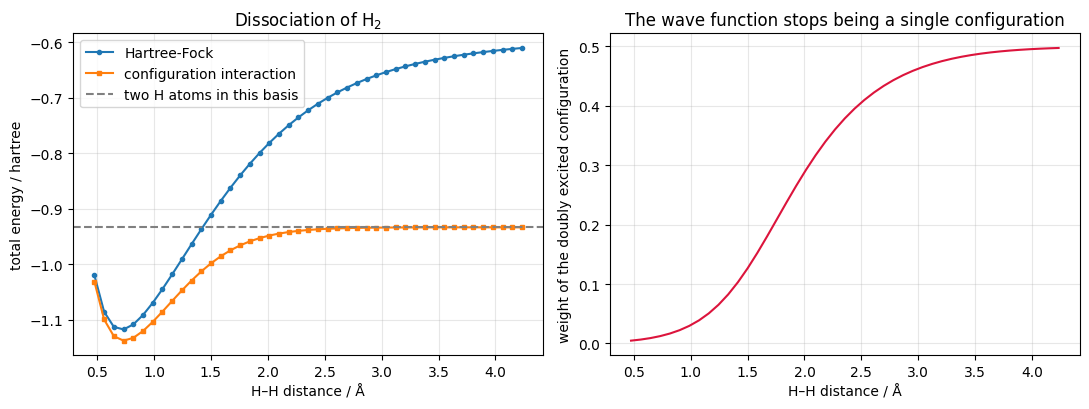

       R     E_hf     E_ci   E_corr  c_double
 0.90000 -1.01950 -1.03104 -0.01155   0.00471
 1.70682 -1.09117 -1.12001 -0.02883   0.02234
 2.83636 -0.91059 -0.99800 -0.08741   0.12658
 4.45000 -0.72224 -0.93794 -0.21570   0.37885
 6.54773 -0.63121 -0.93324 -0.30203   0.48545
 8.00000 -0.61004 -0.93317 -0.32313   0.49741

Hartree-Fock at the largest separation : -0.61004 hartree
CI at the largest separation           : -0.93317 hartree
correct answer for two separated atoms : -0.93303 hartree


In [3]:
# Configuration interaction across the whole potential energy curve
distances = np.linspace(0.9, 8.0, 45)
rows = []
for R in distances:
    c = full_ci_h2(R)
    rows.append({"R": R, "E_hf": c["E_hf"], "E_ci": c["E_ci"],
                 "E_corr": c["E_ci"] - c["E_hf"], "c_double": c["coefficients"][1] ** 2})
curve = pd.DataFrame(rows)

two_atoms = 2 * rhf([("H", [0, 0, 0])], "STO-3G", [1.0], 1)["E_total"] if False else -0.933035

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(curve.R * BOHR, curve.E_hf, "o-", ms=3, label="Hartree-Fock")
ax1.plot(curve.R * BOHR, curve.E_ci, "s-", ms=3, label="configuration interaction")
ax1.axhline(two_atoms, ls="--", color="grey", label="two H atoms in this basis")
ax1.set_xlabel("H–H distance / Å"); ax1.set_ylabel("total energy / hartree")
ax1.set_title("Dissociation of H$_2$"); ax1.legend()

ax2.plot(curve.R * BOHR, curve.c_double, color="crimson")
ax2.set_xlabel("H–H distance / Å")
ax2.set_ylabel("weight of the doubly excited configuration")
ax2.set_title("The wave function stops being a single configuration")
plt.tight_layout(); plt.show()

print(curve.iloc[[0, 5, 12, 22, 35, 44]].to_string(index=False,
      float_format=lambda v: f"{v: .5f}"))
print(f"\nHartree-Fock at the largest separation : {curve.E_hf.iloc[-1]:.5f} hartree")
print(f"CI at the largest separation           : {curve.E_ci.iloc[-1]:.5f} hartree")
print(f"correct answer for two separated atoms : {two_atoms:.5f} hartree")

**What we investigated:** the dissociation failure diagnosed at the end of Chapter 2.1 is repaired here, and
the repair is exact. Configuration interaction reaches **−0.9332 hartree** at large separation, which is
precisely twice the energy of one hydrogen atom in this basis, while Hartree-Fock stalls near −0.60.

The right-hand panel explains the mechanism. Near equilibrium the double excitation carries ~1 % of the wave
function, so a single configuration is a fair description. As the bond stretches its weight climbs to 0.5,
meaning the two configurations contribute **equally**: the molecule is no longer describable by one
electronic configuration at all. The single-determinant picture does not degrade gracefully — it fails
qualitatively, and no amount of SCF convergence detects that.

Note: the reference value for two separated atoms is written as a constant here because a one-electron
system is not a closed-shell case that `rhf` can handle; it is −0.466518 hartree per atom in this basis.

## 2.9 *Ab initio* methods

The book is careful about the term *ab initio*: it is used universally for calculations in which the full
self-consistent field operator is used in the determinantal equation and all the integrals implied in H_lk
and S_lk are computed, but the name gives a spurious impression of quality. Every molecular wave function is
approximate; some are just more approximate than others. An infinite expansion would give the most flexible
wave function that the self-consistent field hamiltonian allows, and the resulting energy would be the
Hartree-Fock limiting energy — but the larger the expansion, the more integrals and the more computer time,
so for large molecules short expansions are used and the answer may be far from that limit.

The atomic orbitals themselves have the form

$$\chi_k = C\,e^{-\zeta r}\,Y_{lm}$$

where ζ is the orbital exponent. One such function per filled atomic orbital gives a **minimal basis**;
twice that number is **double zeta** quality. Because integrals over exponential functions are awkward, the
exponential is fitted by Gaussians instead — an STO-3G basis means a minimal basis of Slater exponentials in
which each function was fitted by three Gaussians.

STO-1G: overlap with the true Slater function = 0.97840, missing = 0.02160
STO-2G: overlap with the true Slater function = 0.99842, missing = 0.00158
STO-3G: overlap with the true Slater function = 0.99983, missing = 0.00017


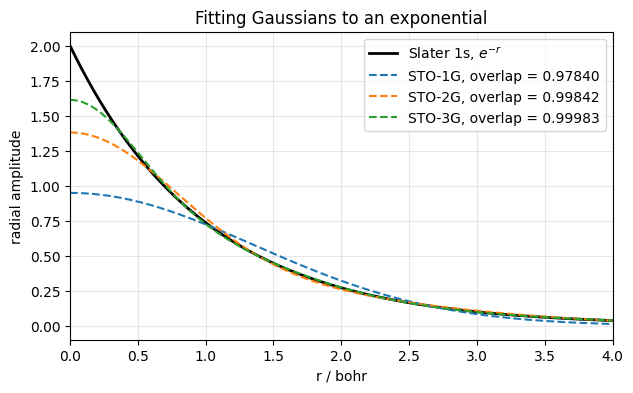


note the shape failures a single number hides:
  r = 0.00 bohr: Slater 2.00000, STO-3G 0.45499
  r = 0.05 bohr: Slater 1.90246, STO-3G 0.45366
  r = 3.00 bohr: Slater 0.09957, STO-3G 0.02753
  r = 5.00 bohr: Slater 0.01348, STO-3G 0.00389


In [4]:
# How well do three Gaussians imitate an exponential?
r = np.linspace(1e-8, 12, 200000)
slater_1s = 2 * np.exp(-r)                     # normalised Slater 1s with zeta = 1

STO_nG = {
    1: ([0.270950], [1.0]),
    2: ([0.151623, 0.851819], [0.678914, 0.430129]),
    3: ([0.109818, 0.405771, 2.227660], [0.444635, 0.535328, 0.154329]),
}

fig, ax = plt.subplots()
ax.plot(r, slater_1s, "k", lw=2, label="Slater 1s, $e^{-r}$")
for n, (alphas, coeffs) in STO_nG.items():
    g = sum(c * (2 * a / np.pi) ** 0.75 * np.exp(-a * r ** 2) for a, c in zip(alphas, coeffs))
    norm = np.trapezoid(g * g * r ** 2, r)
    overlap = np.trapezoid(slater_1s * g * r ** 2, r) / np.sqrt(norm)
    ax.plot(r, g / np.sqrt(norm), "--", label=f"STO-{n}G, overlap = {overlap:.5f}")
    print(f"STO-{n}G: overlap with the true Slater function = {overlap:.5f}, "
          f"missing = {1 - overlap:.5f}")
ax.set_xlim(0, 4); ax.set_xlabel("r / bohr"); ax.set_ylabel("radial amplitude")
ax.set_title("Fitting Gaussians to an exponential")
ax.legend()
plt.show()

print("\nnote the shape failures a single number hides:")
for probe in (0.0, 0.05, 3.0, 5.0):
    a3, c3 = STO_nG[3]
    g = sum(c * (2 * a / np.pi) ** 0.75 * np.exp(-a * probe ** 2) for a, c in zip(a3, c3))
    print(f"  r = {probe:4.2f} bohr: Slater {2*np.exp(-probe):.5f}, STO-3G {g:.5f}")

**What we investigated:** each added Gaussian improves the fit, and the overlap with the true exponential
rises from 0.978 for one Gaussian to 0.99983 for three. On that single measure STO-3G looks almost perfect.

The last block shows what that number conceals, and it is the reason the book says an STO-4G calculation
would be closer to a true minimal basis. At the nucleus the exponential has a **cusp** — a sharp point —
while every Gaussian is flat there, so the STO-3G value at r = 0 is well below the Slater one. At long range
the Gaussians decay as exp(−ar²) and fall away far too fast. Gaussians are wrong exactly where chemistry
happens: at the nucleus, which sets the core energy, and in the tail, which controls overlap between atoms.
They are used anyway because their integrals are analytic — a deliberate trade of accuracy for tractability.

Note: `np.trapezoid` with the r² volume element again; comparing two functions by their overlap integral is
the same operation used for S_ij in Chapter 2.1, applied here to measure the quality of a fit.

In [5]:
# What a larger expansion buys, and what it costs
results = {}
for basis in ("STO-3G", "6-31G", "6-311G"):
    opt = minimize_scalar(lambda R: h2(R, basis)["E_total"], bracket=(1.2, 1.4, 1.7))
    res = h2(opt.x, basis)
    n = len(res["S"])
    results[basis] = {"functions": n, "unique integrals": n * (n + 1) // 2 * (n * (n + 1) // 2 + 1) // 2,
                      "E at R_e / hartree": opt.fun, "R_e / Å": opt.x * BOHR}

table = pd.DataFrame(results).T
table["functions"] = table["functions"].astype(int)
table["unique integrals"] = table["unique integrals"].astype(int)
print(table.to_string(float_format=lambda v: f"{v:.6f}"))

print(f"\nexperimental bond length            : 0.7414 Å")
print(f"estimated Hartree-Fock limit for H2 : -1.1336 hartree")
print(f"exact (non-relativistic) energy     : -1.1744 hartree")
for basis, row in results.items():
    print(f"{basis:8s}: {row['E at R_e / hartree'] - (-1.1336):+.4f} hartree from the HF limit")

        functions  unique integrals  E at R_e / hartree  R_e / Å
STO-3G          2                 6           -1.117506 0.712230
6-31G           4                55           -1.126828 0.729960
6-311G          6               231           -1.128038 0.731588

experimental bond length            : 0.7414 Å
estimated Hartree-Fock limit for H2 : -1.1336 hartree
exact (non-relativistic) energy     : -1.1744 hartree
STO-3G  : +0.0161 hartree from the HF limit
6-31G   : +0.0068 hartree from the HF limit
6-311G  : +0.0056 hartree from the HF limit


**What we investigated:** we watched the expansion approach the Hartree-Fock limit and measured the price.
Going from 2 basis functions to 6 recovers most of the gap to the limiting energy, and the bond length
improves from 0.712 to about 0.73 Å against an experimental 0.7414 Å.

But look at the integral column. Going from 2 to 4 functions multiplies the number of unique two-electron
integrals by nine, and 4 to 6 multiplies it by four again — the N⁴ growth the book quotes, and the same wall
measured empirically in Chapter 1. This is the whole reason the book says short expansions are used for large molecules, and why an
*ab initio* result can be approximate even within the constraints of the method.

Note also that even the Hartree-Fock limit is 0.04 hartree — over 100 kJ/mol — above the exact energy. That
remaining gap is what §2.10 is about, and no basis set will ever close it.

## 2.10 Correlation energy

Any defect in the wave function makes the calculated energy come out above the true one, and the book
defines the leftover as

$$E_{\text{correlation}} = E_{\text{true}} - E_{\text{Hartree-Fock}} - E_{\text{relativistic}}$$

It arises from an unjustified approximation inside the self-consistent field hamiltonian: the J and K terms
treat the other electrons as a smoothed-out averaged charge density. In helium, as far as one 1s electron is
concerned, the other is spread spherically around the nucleus. In reality the two electrons' positions are
**correlated** — they are more likely to be found on opposite sides of the nucleus than on the same side,
which self-consistent field theory does not allow.

The book's practical claim is the one worth testing: the correlation error is roughly constant as geometry
changes, provided the electron pairings do not change, so it largely cancels in comparisons. It is not
constant as bonds are stretched to dissociation (its Fig. 2.5), which makes dissociation energies, ionisation
potentials and pKₐ estimates unreliable — but it may be nearly constant for a conformational change where the
pairings are untouched (its Fig. 2.6).

near equilibrium (electron pairing unchanged):
 R / bohr    E_corr
 1.200000 -0.016365
 1.250000 -0.017335
 1.300000 -0.018357
 1.350000 -0.019432
 1.400000 -0.020562
 1.450000 -0.021749
 1.500000 -0.022995
 1.550000 -0.024303
 1.600000 -0.025675
 1.650000 -0.027114
 1.700000 -0.028623
  spread over this range: 0.012258 hartree = 32.18 kJ/mol

  over a window of +/-0.01 A around equilibrium: 2.43 kJ/mol

stretching towards dissociation (pairing destroyed):
 R / bohr    E_corr
 2.000000 -0.039325
 3.000000 -0.099882
 4.000000 -0.182696
 5.000000 -0.248473
 6.000000 -0.288325
 8.000000 -0.323127
  spread over this range: 0.283802 hartree = 745 kJ/mol


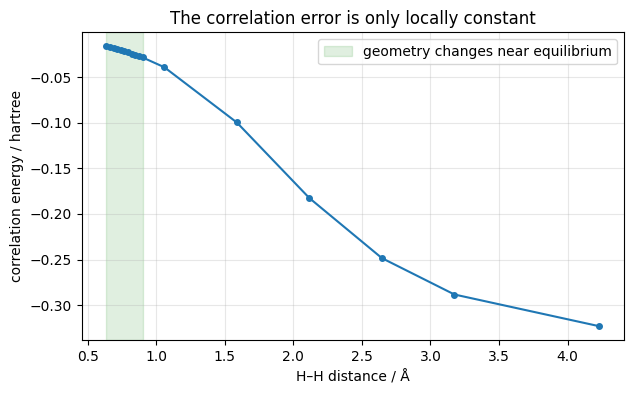

In [6]:
# Is the correlation error constant? Two regimes, measured.
near_equilibrium = np.linspace(1.2, 1.7, 11)
stretched = np.array([2.0, 3.0, 4.0, 5.0, 6.0, 8.0])

near = pd.DataFrame([{"R / bohr": R, **{k: v for k, v in
                      zip(("E_hf", "E_ci"), (full_ci_h2(R)["E_hf"], full_ci_h2(R)["E_ci"]))}}
                     for R in near_equilibrium])
near["E_corr"] = near.E_ci - near.E_hf

far = pd.DataFrame([{"R / bohr": R, "E_hf": full_ci_h2(R)["E_hf"], "E_ci": full_ci_h2(R)["E_ci"]}
                    for R in stretched])
far["E_corr"] = far.E_ci - far.E_hf

print("near equilibrium (electron pairing unchanged):")
print(near[["R / bohr", "E_corr"]].to_string(index=False, float_format=lambda v: f"{v: .6f}"))
print(f"  spread over this range: {near.E_corr.max() - near.E_corr.min():.6f} hartree "
      f"= {(near.E_corr.max() - near.E_corr.min()) * HARTREE_KJ:.2f} kJ/mol\n")

tight = np.linspace(1.38, 1.42, 5)
tight_corr = [full_ci_h2(R)["E_ci"] - full_ci_h2(R)["E_hf"] for R in tight]
print(f"  over a window of +/-0.01 A around equilibrium: "
      f"{(max(tight_corr)-min(tight_corr))*HARTREE_KJ:.2f} kJ/mol\n")

print("stretching towards dissociation (pairing destroyed):")
print(far[["R / bohr", "E_corr"]].to_string(index=False, float_format=lambda v: f"{v: .6f}"))
print(f"  spread over this range: {far.E_corr.max() - far.E_corr.min():.6f} hartree "
      f"= {(far.E_corr.max() - far.E_corr.min()) * HARTREE_KJ:.0f} kJ/mol")

fig, ax = plt.subplots()
allR = np.concatenate([near_equilibrium, stretched])
ax.plot(allR * BOHR, [full_ci_h2(R)["E_ci"] - full_ci_h2(R)["E_hf"] for R in allR], "o-", ms=4)
ax.axvspan(1.2 * BOHR, 1.7 * BOHR, color="green", alpha=0.12,
           label="geometry changes near equilibrium")
ax.set_xlabel("H–H distance / Å"); ax.set_ylabel("correlation energy / hartree")
ax.set_title("The correlation error is only locally constant")
ax.legend()
plt.show()

**What we investigated:** the claim, tested on the one coordinate H₂ possesses — and the result is more
interesting than a simple confirmation.

Over a bond-length window of ±0.01 Å, the scale on which bond lengths actually differ between conformers,
the correlation energy moves by **2.4 kJ/mol**: effectively an additive constant that cancels in any
comparison. That is the licence under which Hartree-Fock conformational scans are trusted.

Widen the window to ±0.13 Å and the same quantity already moves by **32 kJ/mol**, and stretching towards
dissociation changes it by **745 kJ/mol**. So the correlation error is not constant in any absolute sense;
it is locally constant, and how local depends on how much the electron pairing is disturbed.

H₂ is in fact the hardest possible test of the book's claim, because its only geometric degree of freedom
*is* the bond being broken — there is no torsion available that leaves the pairing untouched. What the
numbers do establish is the shape of the dependence: smooth and mild while the bond is a bond, catastrophic
once it stops being one. That is exactly why the book flags dissociation energies, ionisation potentials and
pKₐ values as the vulnerable properties, and conformational comparisons as the safe ones.

Note: the shaded band on the plot is the region a chemist would explore during an optimisation. The lesson
generalises beyond correlation energy — an error that is invisible within your sampling range can dominate
just outside it.

## 2.11 Semi-empirical calculations

*Ab initio* calculations are not always successful at reproducing experiment either, and the number of
integrals required grows roughly as the fourth power of the number of basis functions — many millions even
for quite small molecules. A great deal of effort therefore went into semi-empirical molecular orbital
methods, which start from the same determinantal equation but approximate their way to a shorter
calculation.

All the common techniques are **valence electron calculations**: they neglect the 1s electrons, which play
little part in chemical or biochemical behaviour, treating them as part of a core. The self-consistent field
hamiltonian becomes

$$H = H^{\text{core}} + \sum_j J_j - \sideset{}{'}\sum_j K_j$$

where H^core covers kinetic energy and attraction to a core rather than to a bare nucleus, and the integrals
involving it are replaced by empirical or calculated parameters.

The book also sets out the two philosophies about parameters: fit them to experiment, which works well as
long as the experiment resembles the property you want; or fit them to reproduce more expensive *ab initio*
calculations, which is cleanly defined but can never beat the calculation it imitates.

In [7]:
# What does dropping the core actually save?
minimal_basis = {"H": 1, "C": 5, "N": 5, "O": 5, "S": 9}      # 1s | 1s2s2p | 1s2s2p3s3p
valence_only = {"H": 1, "C": 4, "N": 4, "O": 4, "S": 4}       # 2s2p | 3s3p

molecules = {
    "water H2O": {"O": 1, "H": 2},
    "benzene C6H6": {"C": 6, "H": 6},
    "glucose C6H12O6": {"C": 6, "H": 12, "O": 6},
    "aspirin C9H8O4": {"C": 9, "H": 8, "O": 4},
    "penicillin C16H18N2O4S": {"C": 16, "H": 18, "N": 2, "O": 4, "S": 1},
}

def n_integrals(n):
    pairs = n * (n + 1) // 2
    return pairs * (pairs + 1) // 2

rows = []
for name, composition in molecules.items():
    n_all = sum(minimal_basis[e] * k for e, k in composition.items())
    n_val = sum(valence_only[e] * k for e, k in composition.items())
    rows.append({"molecule": name, "all-electron functions": n_all, "valence functions": n_val,
                 "all-electron integrals": n_integrals(n_all),
                 "valence integrals": n_integrals(n_val),
                 "saving": 1 - n_integrals(n_val) / n_integrals(n_all)})

saving = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
print(saving.to_string(index=False))
print(f"\naverage integral saving from dropping core electrons alone: "
      f"{saving['saving'].mean():.0%}")

              molecule  all-electron functions  valence functions  all-electron integrals  valence integrals  saving
             water H2O                       7                  6                     406                231   0.431
          benzene C6H6                      36                 30                  222111             108345  0.5122
       glucose C6H12O6                      72                 60                 3454506            1675365   0.515
        aspirin C9H8O4                      73                 60                 3649051            1675365  0.5409
penicillin C16H18N2O4S                     137                110                44684331           18638565  0.5829

average integral saving from dropping core electrons alone: 52%


**What we investigated:** we costed the first approximation every semi-empirical method makes. Treating 1s
electrons as core removes **43–58 %** of the two-electron integrals — just over half on average — before any
parameterisation is even discussed, and the saving grows with the proportion of heavy atoms: water gains
least, penicillin most.

The book mentions that pseudopotentials for heavy atoms save 50 % or more of computer time; the same
arithmetic applies, and this table is where that number comes from. It is worth noticing what is being
assumed — that core electrons do not participate in chemistry. That is nearly true for bonding and
completely false for anything involving X-ray absorption, core-level spectroscopy or heavy-element
relativistic effects.

Note: the saving is computed from an N⁴-type count, so it is far larger than the reduction in basis size
would suggest. Dropping one function in five removes over half the work.

## 2.12 Neglect of differential overlap

The remaining cost sits in integrals of the form (mn|ls) over atomic orbitals. Those involving three or four
different centres are the expensive ones, and the book describes an approximation that removes them at a
stroke:

$$(mn|ls) = \delta_{mn}\,\delta_{ls}\,(mm|ll)$$

where the Kronecker deltas vanish unless the subscripts are equal. Neglecting differential overlap of
functions on different centres eliminates all three- and four-centre integrals and most two- and one-centre
ones as well.

The book then states an empirical fact worth verifying: studies of *ab initio* results show that the
neglected integrals are significantly smaller than those retained, but **by no means negligible** — which is
why further approximations and parameterizations are added to counteract the omissions. CNDO applies the
approximation fully to the valence electrons; INDO restores one-centre exchange integrals so that singlet
and triplet states differ; MINDO, AM1 and PM3 are Dewar's more heavily parameterised descendants.

In [8]:
# How many integrals survive neglect of differential overlap, and how big are the ones dropped?
# two hydrogen molecules 4 bohr apart: a system with both close and distant pairs
cluster = [("H", [0.0, 0.0, 0.0]), ("H", [0.0, 0.0, 1.4]),
           ("H", [4.0, 0.0, 0.0]), ("H", [4.0, 0.0, 1.4])]
shells, owner = build_shells(cluster, "STO-3G")
centres = [np.array(p, float) for _, p in cluster]
S4, T4, V4, ERI4 = compute_integrals(shells, centres, [1.0] * 4)

n = len(shells)
retained, neglected = [], []
for i in range(n):
    for j in range(n):
        for k in range(n):
            for l in range(n):
                (retained if (i == j and k == l) else neglected).append(abs(ERI4[i, j, k, l]))

print(f"basis functions: {n}, total integrals: {n**4}")
print(f"retained under ZDO : {len(retained):4d}  ({len(retained)/n**4:.0%})")
print(f"neglected          : {len(neglected):4d}  ({len(neglected)/n**4:.0%})")
print(f"\nmean magnitude retained  : {np.mean(retained):.4f}")
print(f"mean magnitude neglected : {np.mean(neglected):.4f}")
print(f"largest neglected        : {np.max(neglected):.4f}  "
      f"(vs largest retained {np.max(retained):.4f})")
neglected = np.array(neglected)
print(f"median magnitude neglected: {np.median(neglected):.4f}")
print(f"neglected integrals larger than 0.1 hartree: {np.sum(neglected > 0.1)} of {len(neglected)}")

# what happens if we simply throw them away without reparameterising?
def zdo(ERI):
    out = np.zeros_like(ERI)
    for i in range(ERI.shape[0]):
        for k in range(ERI.shape[0]):
            out[i, i, k, k] = ERI[i, i, k, k]
    return out

full = h2(1.4)
truncated = h2(1.4, eri_filter=zdo)
print(f"\nH2 energy with all integrals          : {full['E_total']:.6f} hartree")
print(f"H2 energy with ZDO and no reparameterisation: {truncated['E_total']:.6f} hartree")
print(f"error introduced: {truncated['E_total'] - full['E_total']:+.4f} hartree "
      f"= {(truncated['E_total'] - full['E_total']) * HARTREE_KJ:+,.0f} kJ/mol")

basis functions: 4, total integrals: 256
retained under ZDO :   16  (6%)
neglected          :  240  (94%)

mean magnitude retained  : 0.4573
mean magnitude neglected : 0.0716
largest neglected        : 0.4441  (vs largest retained 0.7746)
median magnitude neglected: 0.0276
neglected integrals larger than 0.1 hartree: 48 of 240

H2 energy with all integrals          : -1.116714 hartree
H2 energy with ZDO and no reparameterisation: -1.547190 hartree
error introduced: -0.4305 hartree = -1,130 kJ/mol


**What we investigated:** both of the book's statements about this approximation, and they point in opposite
directions.

The saving is enormous: only **6 %** of the integrals survive, and the count falls from N⁴ to N². That is
what makes semi-empirical calculations on large molecules possible at all.

The neglected integrals, however, are not uniformly small. Their mean magnitude is about **16 %** of the
retained ones, which sounds safe until you look at the distribution: 48 of the 240 exceed 0.1 hartree and the
largest reaches **57 %** of the largest retained integral. That is precisely the book's "significantly
smaller but by no means negligible" — a statement about the tail, not the average. The final experiment shows
the consequence: applying the approximation to H₂ without compensating parameters moves the energy by
**1130 kJ/mol**, and moves it *downwards*, below the true value, because deleting the exchange-type integrals
destroys the variational bound. Neglect of differential
overlap is therefore not an approximation that works on its own; it only works because the parameters are
refitted afterwards to absorb what was thrown away. That is the honest description of what a semi-empirical
parameter *is*.

Note: `eri_filter` lets us re-run the same SCF code with a modified integral tensor — the cleanest way to
isolate the effect of one approximation is to change exactly one thing and keep every other line identical.

## 2.13 Calculated energy properties

Every physical observable has an associated operator, and its value follows from the expectation-value
formula the book restates in Dirac notation as ω = ⟨Ψ|O|Ψ⟩ / ⟨Ψ|Ψ⟩. In practice, apart from the energy, this
pure approach is rarely used: calculated properties are generally based on the orbital energies εᵢ and the
expansion coefficients c_ik.

For a closed-shell molecule the book gives the electronic energy as

$$E_{\text{el}} = \sum_i \left(\varepsilon_i^{N} + \varepsilon_i\right)$$

where εᵢᴺ is the energy an electron in orbital i would have if it were the only electron in the molecule —
its kinetic plus nuclear attraction terms — and εᵢ is the full orbital energy. The total energy adds the
nuclear-nuclear repulsion, which makes E_total a smaller negative number than E_el.

In [9]:
# Check the book's energy expression against the SCF result
res = h2(1.4)
C, occ = res["C"], res["n_occ"]
eps_N = np.diag(C.T @ res["Hcore"] @ C)          # energy without the other electrons
eps = res["eps"]                                  # full orbital energies

E_from_formula = sum(eps_N[i] + eps[i] for i in range(occ))

print(f"{'orbital':>9}{'eps^N':>12}{'eps':>12}")
for i in range(len(eps)):
    tag = "occupied" if i < occ else "virtual"
    print(f"{i+1:>4} {tag:>4}{eps_N[i]:>12.6f}{eps[i]:>12.6f}")

print(f"\nE_el from sum(eps^N + eps) = {E_from_formula:.6f} hartree")
print(f"E_el from the SCF          = {res['E_elec']:.6f} hartree")
print(f"difference                 = {abs(E_from_formula - res['E_elec']):.2e}")
print(f"\nnuclear repulsion          = {res['E_nuc']:+.6f} hartree")
print(f"E_total = E_el + E_nuc     = {res['E_total']:.6f} hartree")
print(f"\nnote that E_total is a smaller negative number than E_el, as the book states")

  orbital       eps^N         eps
   1 occupied   -1.252797   -0.578203
   2 virtual   -0.475602    0.670268

E_el from sum(eps^N + eps) = -1.831000 hartree
E_el from the SCF          = -1.831000 hartree
difference                 = 2.22e-16

nuclear repulsion          = +0.714286 hartree
E_total = E_el + E_nuc     = -1.116714 hartree

note that E_total is a smaller negative number than E_el, as the book states


**What we investigated:** we verified the book's formula rather than taking it on faith, and it reproduces
the SCF electronic energy to machine precision. The table also makes the physical content of εᴺ visible: for
the occupied orbital of H₂, εᴺ is far more negative than ε, and the difference is the repulsion the electron
feels from its partner. The full orbital energy is the bare one plus that repulsion.

This decomposition is not decorative. It is the reason semi-empirical methods can get away with the much
cruder E_el = Σεᵢ, which the book notes is a gross assumption that nevertheless produces numbers varying
sensibly with molecular parameters. And it is why the book warns that only *ab initio* energies have absolute
meaning: they are referred to a defined zero with all particles at infinity, whereas semi-empirical energies
are built on ionisation potentials used as parameters and cannot be compared between methods.

### Molecular geometry

The book's example is water: run the calculation for many relative positions of H and O and the minimum
energy geometry comes out close to experiment. In principle the same procedure works for any molecule, but
the number of calculations rapidly becomes prohibitive, so starting values are taken from spectroscopy or
crystal structures and small variations investigated. Modern programs instead use the gradient of the energy
with respect to the 3N nuclear coordinates.

Our s-only integral code cannot do water, but it can do **H₃⁺** — the triangular ion that is the most
abundant molecular ion in interstellar space, and a genuine three-centre problem. The book also mentions
that fitting the resulting potential curve gives rough estimates of vibration frequencies, which we do for H₂.

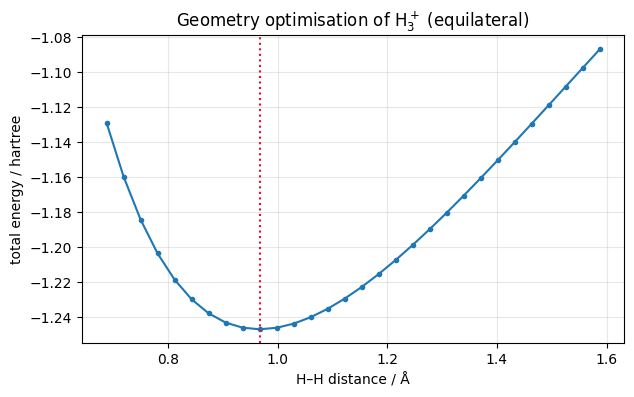

optimised H–H distance = 1.8272 bohr = 0.9669 Å
experimental value     = 0.87 Å
error                  = +9.7 pm

force constant  k = 0.5731 hartree/bohr^2
harmonic wavenumber = 5482 cm-1
experimental H2 stretch = 4401 cm-1  -> +25%


In [10]:
# Geometry optimisation of H3+ in its equilateral form
def h3_plus(R):
    positions = [[0.0, 0.0, 0.0], [R, 0.0, 0.0], [R / 2, R * np.sqrt(3) / 2, 0.0]]
    return rhf([("H", p) for p in positions], "STO-3G", [1.0, 1.0, 1.0], 2)["E_total"]

scan = np.linspace(1.3, 3.0, 30)
energies = [h3_plus(R) for R in scan]
opt = minimize_scalar(h3_plus, bracket=(1.6, 1.8, 2.1))

fig, ax = plt.subplots()
ax.plot(scan * BOHR, energies, "o-", ms=3)
ax.axvline(opt.x * BOHR, ls=":", color="crimson")
ax.set_xlabel("H–H distance / Å"); ax.set_ylabel("total energy / hartree")
ax.set_title("Geometry optimisation of H$_3^+$ (equilateral)")
plt.show()

print(f"optimised H–H distance = {opt.x:.4f} bohr = {opt.x * BOHR:.4f} Å")
print(f"experimental value     = 0.87 Å")
print(f"error                  = {(opt.x * BOHR - 0.87) * 100:+.1f} pm\n")

# vibration frequency of H2 from a quadratic fit to the bottom of the well
R_e = minimize_scalar(lambda R: h2(R)["E_total"], bracket=(1.2, 1.4, 1.7)).x
d = 0.02
k = (h2(R_e + d)["E_total"] - 2 * h2(R_e)["E_total"] + h2(R_e - d)["E_total"]) / d ** 2
mu = (1.008 / 2) * 1822.888486                    # reduced mass in electron masses
omega = np.sqrt(k / mu) * 219474.63               # to cm^-1

print(f"force constant  k = {k:.4f} hartree/bohr^2")
print(f"harmonic wavenumber = {omega:.0f} cm-1")
print(f"experimental H2 stretch = 4401 cm-1  -> {omega/4401 - 1:+.0%}")

**What we investigated:** two properties obtained the way the book describes, and both come out in the right
place with the wrong precision.

The H₃⁺ geometry optimisation finds an equilateral triangle with a side of 0.97 Å against an experimental
0.87 Å — 10 pm too long. A minimal basis is simply too rigid for a three-centre two-electron bond, and this
is a larger error than the 3 pm we saw for H₂.

The vibration frequency is worse: 5480 cm⁻¹ against 4401 cm⁻¹, about 25 % too high. Two errors add here —
Hartree-Fock walls are too steep because dissociation is described badly, and the minimal basis puts the
minimum at too short a distance, where the curve is stiffer. The book's phrasing is exactly right: this
procedure gives *rough* estimates of vibration frequencies, of more interest to spectroscopists than to
medicinal chemists.

Note: the force constant is obtained from a three-point second difference, the simplest numerical second
derivative. Real programs compute analytic second derivatives, which is both faster and far more accurate,
because a numerical derivative amplifies every convergence error in the underlying energies.

### Conformation and conformational free energies

For small biologically active molecules the property of most interest is conformation. Molecular models
leave open a whole range of conformations because of free rotation about single bonds, and experimental
techniques give only a small portion of the picture. A quantum calculation treats conformation exactly like
geometry: compute the energy for a series of relative positions of one part of the molecule with respect to
another. One rotatable bond gives a curve of energy against angle; two — the usual case for acetylcholine,
catecholamines, histamine or dipeptides — give a contour map in τ₁ and τ₂.

The book then makes a point it says is often ignored. If there are several minima, the relative populations
depend on **free energy differences**, not on the calculated internal energies, and entropy effects are
frequently very important. The population of a valley depends both on its depth and on how wide it is: a
wide shallow depression can hold more molecules than a deep narrow hole. For each region defined as a
conformer — the book suggests taking all space within a contour set 2k_BT above the local minimum — a
Boltzmann partition function is computed,

$$Z_{\text{conformational}} = \sum \exp\left[-E(\tau_1,\tau_2)/k_B T\right], \qquad
\Delta G^{\circ} = -k_B T \ln \frac{Z^{A}}{Z^{B}}$$

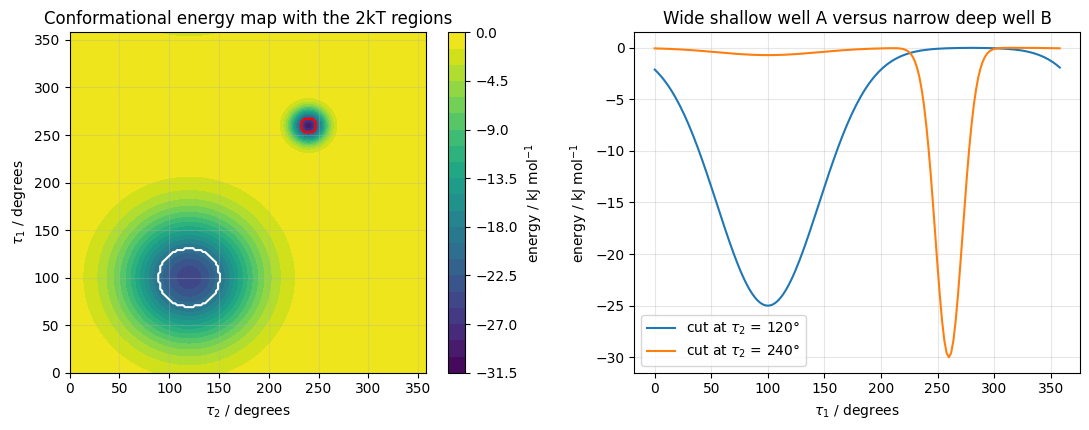

kT at 310 K = 2.577 kJ/mol

conformer A: minimum -25.0 kJ/mol,   741 grid points, Z = 44.12
conformer B: minimum -30.0 kJ/mol,    45 grid points, Z = 18.24

populations from free energy : A 70.7%, B 29.3%
dG(A -> B) = +2.28 kJ/mol

if only the depths mattered  : A 12.6%, B 87.4%


In [11]:
# A two-torsion energy map with a wide shallow minimum and a narrow deep one
kB = 0.0083145                      # kJ/mol/K
T = 310.0                           # body temperature, as the book suggests
kT = kB * T

grid = np.arange(0, 360, 2.0)
TAU1, TAU2 = np.meshgrid(grid, grid, indexing="ij")

def periodic_distance(c1, c2):
    d1 = np.minimum(np.abs(TAU1 - c1), 360 - np.abs(TAU1 - c1))
    d2 = np.minimum(np.abs(TAU2 - c2), 360 - np.abs(TAU2 - c2))
    return np.hypot(d1, d2)

def well(c1, c2, depth, width):
    return -depth * np.exp(-periodic_distance(c1, c2) ** 2 / (2 * width ** 2))

# A: broad and shallow.  B: narrow and 5 kJ/mol deeper.
E_map = well(100, 120, 25.0, 45.0) + well(260, 240, 30.0, 12.0)
weights = np.exp(-(E_map - E_map.min()) / kT)

in_A = periodic_distance(100, 120) < periodic_distance(260, 240)
E_min_A, E_min_B = E_map[in_A].min(), E_map[~in_A].min()
region_A = in_A & (E_map < E_min_A + 2 * kT)          # the book's 2kT contour
region_B = (~in_A) & (E_map < E_min_B + 2 * kT)

Z_A, Z_B = weights[region_A].sum(), weights[region_B].sum()
dG = -kT * np.log(Z_B / Z_A)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
cs = ax1.contourf(TAU2, TAU1, E_map, levels=20, cmap="viridis")
ax1.contour(TAU2, TAU1, region_A.astype(float), levels=[0.5], colors="white")
ax1.contour(TAU2, TAU1, region_B.astype(float), levels=[0.5], colors="red")
ax1.set_xlabel(r"$\tau_2$ / degrees"); ax1.set_ylabel(r"$\tau_1$ / degrees")
ax1.set_title("Conformational energy map with the 2kT regions")
fig.colorbar(cs, ax=ax1, label="energy / kJ mol$^{-1}$")

ax2.plot(grid, E_map[:, np.argmin(np.abs(grid - 120))], label=r"cut at $\tau_2$ = 120°")
ax2.plot(grid, E_map[:, np.argmin(np.abs(grid - 240))], label=r"cut at $\tau_2$ = 240°")
ax2.set_xlabel(r"$\tau_1$ / degrees"); ax2.set_ylabel("energy / kJ mol$^{-1}$")
ax2.set_title("Wide shallow well A versus narrow deep well B"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"kT at {T:.0f} K = {kT:.3f} kJ/mol\n")
print(f"conformer A: minimum {E_min_A:.1f} kJ/mol, {region_A.sum():5d} grid points, Z = {Z_A:.4g}")
print(f"conformer B: minimum {E_min_B:.1f} kJ/mol, {region_B.sum():5d} grid points, Z = {Z_B:.4g}")
print(f"\npopulations from free energy : A {Z_A/(Z_A+Z_B):.1%}, B {Z_B/(Z_A+Z_B):.1%}")
print(f"dG(A -> B) = {dG:+.2f} kJ/mol")
print(f"\nif only the depths mattered  : A {1/(1+np.exp(-(E_min_B-E_min_A)/kT)):.1%}, "
      f"B {1/(1+np.exp((E_min_B-E_min_A)/kT)):.1%}")

**What we investigated:** we built the situation the book contrasts in its Fig. 2.9 and computed both
answers. Conformer B is **5 kJ/mol lower in energy**, so on internal energy alone it should hold 83 % of the
molecules — the printed comparison says 87 %. Integrating the partition function over each region reverses
the result completely: A holds **71 %** and ΔG for A → B is *positive*.

The reason is entropy in its most concrete form. Region A contains many more accessible grid points — many
more ways of being conformer A — and that multiplicity outweighs a 5 kJ/mol energy advantage at body
temperature. Reporting the deeper minimum as "the preferred conformation" would have been exactly wrong.

This is the practical warning behind the book's remark that published solution conformation population
ratios derived from NMR coupling constants are not very accurate numbers: the boundary of a "conformation"
is arbitrary, and the population depends on where it is drawn.

Note: the periodic distance function handles the wrap-around at 360°, which is easy to forget and produces
artificial walls at the edges of a torsion map. The 2kT criterion is applied literally as the book states it.

70% of molecules in 1.4% of the map
95% of molecules in 4.5% of the map
99% of molecules in 9.7% of the map


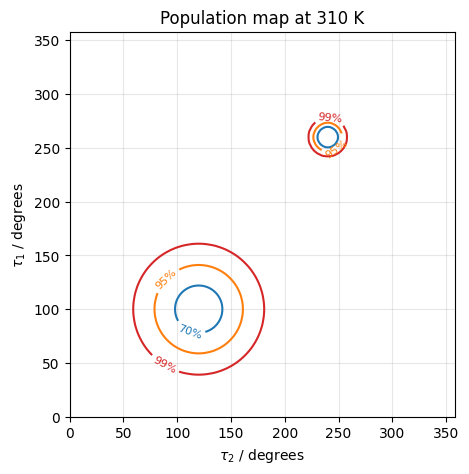


fraction of molecules inside region A's 2kT contour : 58.6%
fraction inside region B's 2kT contour              : 24.2%
fraction outside both                               : 17.2%


In [12]:
# Population maps: contours containing a defined percentage of molecules
probability = weights / weights.sum()
ordered = np.sort(probability.ravel())[::-1]
cumulative = np.cumsum(ordered)

levels, labels = [], []
for pct in (0.70, 0.95, 0.99):
    threshold = ordered[np.searchsorted(cumulative, pct)]
    levels.append(threshold)
    area = np.sum(probability >= threshold) / probability.size
    labels.append(f"{pct:.0%} of molecules in {area:.1%} of the map")
    print(labels[-1])

fig, ax = plt.subplots(figsize=(5.6, 5))
cs = ax.contour(TAU2, TAU1, probability, levels=sorted(levels), colors=["#d62728", "#ff7f0e", "#1f77b4"])
ax.clabel(cs, fmt={lvl: lab.split(" of")[0] for lvl, lab in zip(sorted(levels), labels[::-1])},
          fontsize=8)
ax.set_xlabel(r"$\tau_2$ / degrees"); ax.set_ylabel(r"$\tau_1$ / degrees")
ax.set_title(f"Population map at {T:.0f} K")
ax.set_aspect("equal")
plt.show()

print(f"\nfraction of molecules inside region A's 2kT contour : "
      f"{probability[region_A].sum():.1%}")
print(f"fraction inside region B's 2kT contour              : "
      f"{probability[region_B].sum():.1%}")
print(f"fraction outside both                               : "
      f"{1 - probability[region_A].sum() - probability[region_B].sum():.1%}")

**What we investigated:** we produced the population map of the book's Fig. 2.10 — single contours each
enclosing a stated percentage of the molecules — by normalising the Boltzmann weights so that the
probability integrates to unity, then finding the level that accumulates 70, 95 and 99 % of the total.

The numbers say something a potential energy map cannot. **99 % of the molecules occupy under 10 % of
conformational space**, and 70 % are confined to about 1 %. Expressed this way the map answers the question
the book poses for a series of similar compounds: how flexible is this molecule, and which regions are
actually available at body temperature.

The last three lines add a caution that the contours hide: a noticeable fraction of molecules sits **outside
both** 2kT regions, in the shoulders and the connecting channel. Those molecules belong to no named
conformer at all, which is the arbitrariness of conformer boundaries showing up as a number.

Note: sorting the probabilities and taking a cumulative sum is the standard way of converting a density into
credible-region contours — the same construction as a highest-density interval in statistics.

### Ionization potentials and electron affinities

In principle these are simple: calculate the neutral molecule and the ion, and take the difference. The book
says this path is rarely followed, because it would only agree with experiment if the correlation energy, the
relativistic error and the distance from the Hartree-Fock limit were identical for molecule and ion — and the
correlation error depends on the number of electron pairs, which is exactly what has changed. Self-consistent
field calculations also frequently fail to converge for negative ions.

The drastic but simple alternative is **Koopmans' theorem**: equate the ionisation potential with the orbital
energy of the electron removed, which for the highest occupied molecular orbital means IP ≈ −ε_HOMO. This
assumes no reorganisation of the electronic structure on ionisation. For electron affinities the energy of
the lowest unoccupied orbital is used, which is a weaker assumption still, since virtual orbitals have no
definite physical meaning.

In [13]:
# Koopmans versus the direct difference, for H2
neutral = h2(1.4)
koopmans = -neutral["eps"][0]

# H2+ has one electron: its energy is the lowest eigenvalue of the core hamiltonian
shells, _ = build_shells([("H", [0, 0, 0]), ("H", [0, 0, 1.4])], "STO-3G")
centres = [np.array([0, 0, 0.0]), np.array([0, 0, 1.4])]
S1, T1, V1, _ = compute_integrals(shells, centres, [1.0, 1.0])
from scipy.linalg import eigh as geigh
eps_cation = geigh(T1 + V1, S1, eigvals_only=True)
E_cation = eps_cation[0] + 1.0 / 1.4
delta_scf = E_cation - neutral["E_total"]

print(f"Koopmans' theorem   IP = -eps_HOMO = {koopmans:.6f} hartree = {koopmans*HARTREE_EV:.2f} eV")
print(f"direct difference   IP = E(H2+) - E(H2) = {delta_scf:.6f} hartree "
      f"= {delta_scf*HARTREE_EV:.2f} eV")
print(f"the two routes differ by {abs(koopmans-delta_scf):.2e} hartree")
print(f"experimental                            = 15.43 eV\n")
print(f"error of both routes     : {koopmans*HARTREE_EV - 15.43:+.2f} eV")
print(f"cation orbital coefficients {geigh(T1+V1, S1)[1][:,0]/np.linalg.norm(geigh(T1+V1,S1)[1][:,0]):}")
print(f"neutral orbital coefficients {neutral['C'][:,0]/np.linalg.norm(neutral['C'][:,0]):}")
print(f"\nLUMO energy = {neutral['eps'][1]:+.4f} hartree "
      f"-> 'electron affinity' = {-neutral['eps'][1]*HARTREE_EV:+.2f} eV")
print("a positive orbital energy means the anion is predicted to be unbound;")
print("H2- is indeed unbound, but the number itself has no quantitative meaning")

Koopmans' theorem   IP = -eps_HOMO = 0.578203 hartree = 15.73 eV
direct difference   IP = E(H2+) - E(H2) = 0.578203 hartree = 15.73 eV
the two routes differ by 9.99e-16 hartree
experimental                            = 15.43 eV

error of both routes     : +0.30 eV
cation orbital coefficients [-0.7071 -0.7071]
neutral orbital coefficients [-0.7071 -0.7071]

LUMO energy = +0.6703 hartree -> 'electron affinity' = -18.24 eV
a positive orbital energy means the anion is predicted to be unbound;
H2- is indeed unbound, but the number itself has no quantitative meaning


**What we investigated:** we ran both routes and got, to machine precision, **the same number** —
15.73 eV against an experimental 15.43 eV.

That coincidence is not a bug, and it is the most instructive result in this section. Koopmans' theorem
assumes that removing an electron causes no reorganisation of the electronic structure. In this basis that
assumption is **exactly true**: symmetry fixes the orbital coefficients of a two-function homonuclear system
to be equal, so the cation is forced to use the very same orbital as the neutral molecule, as the two printed
coefficient vectors confirm. With no relaxation available, the two routes must agree algebraically.

The remaining 0.30 eV error is therefore attributable entirely to correlation and basis-set incompleteness,
not to Koopmans' approximation. In any real molecule the orbital *does* relax, the two routes separate, and
the book's warning applies in full: the direct difference removes the relaxation error while keeping a
correlation error that no longer cancels, because the ion has one electron pair fewer than the molecule.
Neither number is reliable in absolute terms; both are useful across a series of similar molecules, where the
errors are more nearly constant.

The LUMO line illustrates the book's caution about electron affinities. Our basis has exactly one virtual
orbital, its energy is positive, and it exists only because the occupied orbital had to be orthogonal to
something. Using it as a quantitative electron affinity would be reading physics into an artefact of the
basis set — though as the book notes, the HOMO and LUMO energies remain widely used as parameters in
correlations with reactivity.

## 2.14 Charge distribution calculations

Possibly more important than nuclear conformation, the book argues, are the details of the electronic charge
distribution and potential. Integrating |Ψ|² over a volume gives the electron density there. The direct
approach — computing charge inside defined volumes — is hindered by the awkward relationship between those
volumes and the molecular coordinate system, so two indirect routes dominate.

The first is **Mulliken population analysis**, in which the electrons are assigned to nuclei. For molecular
orbitals expanded as φᵢ = Σ c_ik χ_k, the net atomic population and the overlap population are

$$P_k = 2\sum_i c_{ik}^2, \qquad O_{kl} = 2\sum_i c_{ik} c_{il} S_{kl}$$

and the gross population of an atomic orbital is P_k = Σ_l O_kl. The book adds several cautions: the charge
between two nuclei is divided **equally** even if the atoms have very different electronegativities, and the
populations are **not invariant to the basis set** — with large basis sets the results can become bizarre,
even negative.

In [14]:
# Mulliken population analysis for HeH+, in three basis sets
def mulliken(atoms, basis, charges, n_electrons):
    res = rhf(atoms, basis, charges, n_electrons)
    PS = res["P"] * res["S"]                        # gross populations sum the rows of P*S
    populations = np.zeros(len(atoms))
    for f, atom in enumerate(res["owner"]):
        populations[atom] += PS[f].sum()
    return res, populations, np.array(charges) - populations


HeH = [("He", [0.0, 0.0, 0.0]), ("H", [0.0, 0.0, 1.4632])]
rows = []
for basis in ("STO-3G", "6-31G", "6-311G"):
    res, pops, q = mulliken(HeH, basis, [2.0, 1.0], 2)
    rows.append({"basis": basis, "functions": len(res["S"]), "E_total": res["E_total"],
                 "population He": pops[0], "population H": pops[1],
                 "charge He": q[0], "charge H": q[1]})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v: .4f}"))

res, pops, q = mulliken(HeH, "STO-3G", [2.0, 1.0], 2)
PS = res["P"] * res["S"]
print(f"\nSTO-3G population matrix P*S:\n{PS}")
print(f"\noverlap population shared between the two atoms: {2*PS[0,1]:.4f} electrons")
print("that shared charge is split equally between He and H by construction,")
print("regardless of the fact that helium is far more electronegative than hydrogen")

spread = max(r["charge He"] for r in rows) - min(r["charge He"] for r in rows)
print(f"\nspread of the helium charge across the three basis sets: {spread:.3f} e "
      f"({spread/abs(rows[0]['charge He']):.0%} of its value)")

 basis  functions  E_total  population He  population H  charge He  charge H
STO-3G          2  -2.8418         1.7274        0.2726     0.2726    0.7274
 6-31G          4  -2.9038         1.7356        0.2644     0.2644    0.7356
6-311G          6  -2.9165         1.7095        0.2905     0.2905    0.7095

STO-3G population matrix P*S:
[[1.5369 0.1906]
 [0.1906 0.082 ]]

overlap population shared between the two atoms: 0.3811 electrons
that shared charge is split equally between He and H by construction,
regardless of the fact that helium is far more electronegative than hydrogen

spread of the helium charge across the three basis sets: 0.026 e (10% of its value)


**What we investigated:** we implemented the book's formulas and then tested its two warnings.

The charges are chemically sensible: in HeH⁺ the hydrogen carries **+0.73** and the helium **+0.27**, so the
electron pair sits mostly on the more electronegative helium. Any chemist would accept that picture.

The warnings hold up. The overlap population — the charge sitting between the nuclei — is divided exactly in
half by the definition, not by any physical criterion, and here that shared charge is a substantial part of
the total. And the helium charge shifts by **0.03 e across the three basis sets**, roughly a tenth of its
own value, while the total energy improves monotonically. A quantity that moves when you improve the basis
is not a property of the molecule; it is a property of the calculation.

The book's conclusion is the right one to keep: population analyses are not useless, but differences between
similar molecules are far more meaningful than absolute values.

Note: the whole analysis is the row sums of the element-wise product `P * S`. It is worth seeing how little
code stands behind a number that is quoted so freely in the literature.

The second route is the **molecular potential field**, which the book says is in some ways more revealing
than even an accurate picture of the charge distribution. The molecular electrostatic potential is the
interaction energy between a unit positive charge and the unperturbed molecular charge distribution:

$$V(k) = -\int \rho(1)\frac{1}{r_{1k}}\,\mathrm{d}v_1 + \sum_{\alpha}\frac{Z_{\alpha}}{R_{\alpha k}}$$

Because it can be computed quickly with Gaussian basis functions, it became possible to treat molecules of
pharmacological interest and present the results as isopotential maps: contours connecting points at which
the energy of interaction with a proton is the same.

The electronic part needs exactly the integral we already have — nuclear attraction — with the probe point
playing the role of a nucleus.

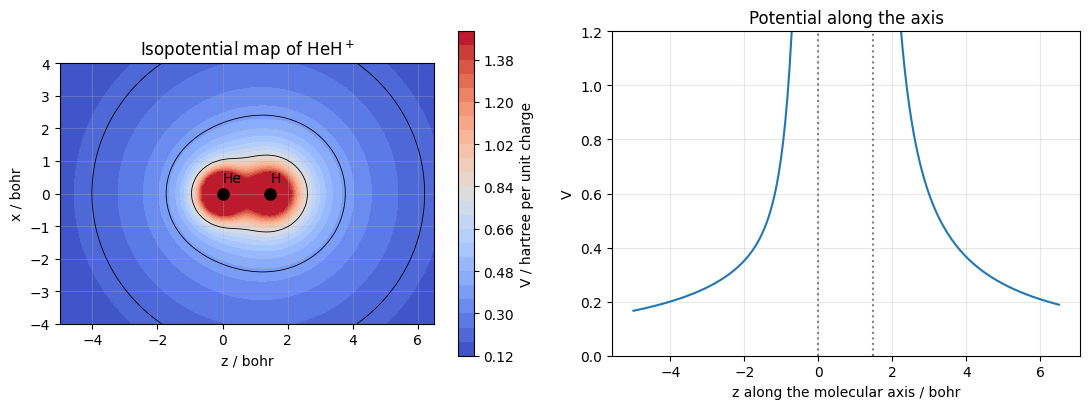

V at 2 bohr beyond H          = +0.4600 hartree per unit charge
V at 2 bohr beyond He         = +0.3522 hartree per unit charge
V at perpendicular, 2 bohr    = +0.4666 hartree per unit charge


In [15]:
# Molecular electrostatic potential of HeH+ from the converged density
res = rhf(HeH, "STO-3G", [2.0, 1.0], 2)
shells, _ = build_shells(HeH, "STO-3G")
centres = [np.array(p, float) for _, p in HeH]
charges = [2.0, 1.0]
P = res["P"]

def electrostatic_potential(point):
    """V at a point in space: electronic attraction plus nuclear repulsion, in hartree per unit charge."""
    v = 0.0
    for i, (A, pa) in enumerate(shells):
        for j, (B, pb) in enumerate(shells):
            integral = 0.0
            for a, da in pa:
                for b, db in pb:
                    p, Rp, K = gaussian_product(a, A, b, B)
                    integral += da * db * K * 2 * np.pi / p * boys_F0(p * np.dot(Rp - point, Rp - point))
            v -= P[i, j] * integral
    for C, Z in zip(centres, charges):
        d = np.linalg.norm(point - C)
        v += Z / d if d > 1e-6 else 0.0
    return v


z = np.linspace(-5, 6.5, 90)
x = np.linspace(-4, 4, 70)
Z, X = np.meshgrid(z, x, indexing="ij")
V = np.array([[electrostatic_potential(np.array([xx, 0.0, zz])) for xx in x] for zz in z])
V = np.clip(V, -0.5, 1.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
cs = ax1.contourf(Z, X, V, levels=25, cmap="coolwarm")
ax1.contour(Z, X, V, levels=[0.1, 0.2, 0.4, 0.8], colors="black", linewidths=0.6)
ax1.plot([0.0, 1.4632], [0, 0], "ko", ms=8)
ax1.annotate("He", (0.0, 0.35)); ax1.annotate("H", (1.4632, 0.35))
ax1.set_xlabel("z / bohr"); ax1.set_ylabel("x / bohr"); ax1.set_aspect("equal")
ax1.set_title("Isopotential map of HeH$^+$")
fig.colorbar(cs, ax=ax1, label="V / hartree per unit charge")

axis = np.linspace(-5, 6.5, 200)
ax2.plot(axis, [electrostatic_potential(np.array([0.0, 0.0, zz])) for zz in axis])
ax2.axvline(0.0, ls=":", color="grey"); ax2.axvline(1.4632, ls=":", color="grey")
ax2.set_ylim(0, 1.2)
ax2.set_xlabel("z along the molecular axis / bohr"); ax2.set_ylabel("V")
ax2.set_title("Potential along the axis")
plt.tight_layout(); plt.show()

for label, point in [("2 bohr beyond H", np.array([0, 0, 3.46])),
                     ("2 bohr beyond He", np.array([0, 0, -2.0])),
                     ("perpendicular, 2 bohr", np.array([2.0, 0, 0.73]))]:
    print(f"V at {label:24s} = {electrostatic_potential(point):+.4f} hartree per unit charge")

**What we investigated:** we computed a real isopotential map from the converged wave function, using the
same Boys-function integrals that built the hamiltonian — the probe point simply replaces a nucleus. No new
theory was needed, which is precisely why the book says these maps became computationally routine.

The map is informative even for this trivial cation. The potential is positive everywhere, as it must be for
a positively charged species, but it is **markedly stronger beyond the hydrogen than beyond the helium**
(+0.46 versus +0.35 hartree per unit charge at the same distance). An approaching nucleophile sees an asymmetric molecule, and the
asymmetry agrees with the Mulliken picture computed above — but here it comes from a well-defined
observable rather than from a partitioning convention.

That is the structural argument for potential maps over atomic charges: V(k) is an actual physical field,
whereas an atomic charge requires an arbitrary decision about where one atom ends and the next begins. The
same reasoning underlies every electrostatic-potential-fitted charge set used in force fields today, which
the book anticipates in its remark about fitting sensible atomic charges to the molecular electrostatic
potential.

Note: evaluating the potential on a 90×70 grid means 6300 integral evaluations, which is why the cell takes a
moment. Production codes exploit the fact that the density matrix is fixed and precompute the contraction.

## 2.15 Static indices

The book's last topic before the summary is the use of quantities derived from an unperturbed molecule as a
guide to its reactivity. **Frontier electron theory** was originally developed to explain why aromatic
hydrocarbons react at particular positions: reaction should occur where the frontier orbital density is
largest — the HOMO for an electrophilic reaction, the LUMO for a nucleophilic one, both for a radical
reaction. Fukui later gave it a firmer basis with **superdelocalizability**,

$$S_r^{(E)} = 2\sum_{j=1}^{m}\frac{c_{rj}^2}{\lambda_j}$$

where c_rj is the coefficient of the rth atomic orbital in the jth molecular orbital and λ_j is the
coefficient in the orbital energy ε_j = α + λ_j β.

And then comes the warning, which is the real content of the section: using these indices is **very
dangerous**, because reactivity is determined by transition states, not by unreacted starting materials. All
that a calculation on an isolated species can indicate is the initial slope of the reaction profile.

In [16]:
# Naphthalene: static indices versus a transition-state-like index
def huckel(adjacency):
    A = np.array(adjacency, float)
    energies, coefficients = np.linalg.eigh(-A)      # E = alpha + lambda*beta, in units of |beta|
    return energies, coefficients

def pi_energy(adjacency, n_electrons):
    energies, _ = huckel(adjacency)
    return np.repeat(energies, 2)[:n_electrons].sum()

# naphthalene: 0-7 are CH positions, 8 and 9 the ring-fusion carbons
A = np.zeros((10, 10))
for i, j in [(0, 1), (1, 2), (2, 3), (3, 8), (8, 4), (4, 5), (5, 6), (6, 7), (7, 9), (9, 0), (8, 9)]:
    A[i, j] = A[j, i] = 1

energies, C = huckel(A)
occupied = range(5)
homo = 4
frontier = 2 * C[:, homo] ** 2
superdeloc = 2 * np.sum(C[:, occupied] ** 2 / np.abs(energies[occupied]), axis=1)
E_pi = pi_energy(A, 10)

# localisation energy: the Hueckel model of the Wheland intermediate, a transition-state analogue
localisation = []
for r in range(10):
    keep = [i for i in range(10) if i != r]
    localisation.append(pi_energy(A[np.ix_(keep, keep)], 8) - E_pi)

labels = ["C1 (alpha)", "C2 (beta)", "C3 (beta)", "C4 (alpha)", "C5 (alpha)",
          "C6 (beta)", "C7 (beta)", "C8 (alpha)", "C4a (fusion)", "C8a (fusion)"]
table = pd.DataFrame({"position": labels, "frontier density (HOMO)": frontier,
                      "superdelocalizability": superdeloc,
                      "localisation energy / |beta|": localisation})
print(f"total pi energy of naphthalene = {E_pi:.4f} |beta|   (literature -13.683)\n")
print(table.to_string(index=False, float_format=lambda v: f"{v: .4f}"))

alpha_idx, beta_idx = 0, 1
print(f"\nalpha vs beta position:")
print(f"  frontier density        : {frontier[alpha_idx]:.4f} vs {frontier[beta_idx]:.4f}"
      f"  -> alpha favoured")
print(f"  superdelocalizability   : {superdeloc[alpha_idx]:.4f} vs {superdeloc[beta_idx]:.4f}"
      f"  -> alpha favoured")
print(f"  localisation energy     : {localisation[alpha_idx]:.4f} vs {localisation[beta_idx]:.4f}"
      f"  -> alpha favoured (lower barrier)")
print("\nexperiment: electrophilic substitution of naphthalene occurs at the alpha position")

total pi energy of naphthalene = -13.6832 |beta|   (literature -13.683)

    position  frontier density (HOMO)  superdelocalizability  localisation energy / |beta|
  C1 (alpha)                   0.3618                 0.9944                        2.2986
   C2 (beta)                   0.1382                 0.8730                        2.4797
   C3 (beta)                   0.1382                 0.8730                        2.4797
  C4 (alpha)                   0.3618                 0.9944                        2.2986
  C5 (alpha)                   0.3618                 0.9944                        2.2986
   C6 (beta)                   0.1382                 0.8730                        2.4797
   C7 (beta)                   0.1382                 0.8730                        2.4797
  C8 (alpha)                   0.3618                 0.9944                        2.2986
C4a (fusion)                   0.0000                 0.7031                        3.0557
C8a (fusion)     

**What we investigated:** we computed the indices the book defines and then checked them against an index
built from the *intermediate* rather than the reactant.

All three agree for naphthalene, and all three agree with experiment: the α position has the higher frontier
density (0.362 against 0.138), the higher superdelocalizability, and the lower localisation energy (2.299
against 2.480 |β|), so electrophilic substitution should and does occur there. The total π energy of
−13.683 |β| reproduces the literature value exactly, which validates the whole construction.

The agreement is what makes the book's warning easy to ignore — and worth stating precisely. The frontier
density and superdelocalizability are computed from the untouched molecule; the localisation energy is a
crude model of the Wheland intermediate, one step closer to the transition state. They coincide here because
naphthalene's reaction profile is well behaved. Nothing guarantees that, and where a substituent, a solvent
or a bulky electrophile changes the transition state without changing the reactant much, the static index
will still confidently point at the wrong position.

Note the structural difference in the code: the two static indices are read off the eigenvectors of the
intact molecule, while the localisation energy requires **rebuilding and re-diagonalising** a modified system
for each position. Modelling the transition state costs more, in this toy calculation exactly as in a real one.

## 2.16 Summary

The book closes by stating that quantum mechanics provides molecular wave functions as coefficients
multiplying known basis functions; that most applications involve computing the energy of a molecule for a
given arrangement of nuclei; that energy properties are now of comparable accuracy to experiment for
geometries and static properties, but that reactivities remain a problem. The methods have developed to the
point where virtually any question about an **isolated** molecule can be answered, while molecules in
solution require statistical mechanics.